# Exercícios
## 1) Modificar a profundidade da árvore e comparar resultados
**Objetivo:**

Entender como a profundidade (max_depth) influencia o underfitting e o overfitting.

Altere o parâmetro da árvore de decisão:

model = DecisionTreeClassifier(max_depth=3)

E teste diferentes valores:

max_depth = 1;
max_depth = 5;
max_depth = None (profundidade ilimitada)

Para cada profundidade:

1. Treine o modelo.
2. Plote a árvore de decisão.
3. Gere a fronteira de decisão.
4. Calcule as métricas: accuracy, precisão, recall, F1.

**Pergunta final:** Como a profundidade influencia o overfitting e o desempenho no teste?



Árvore de Decisão com max_depth = 1


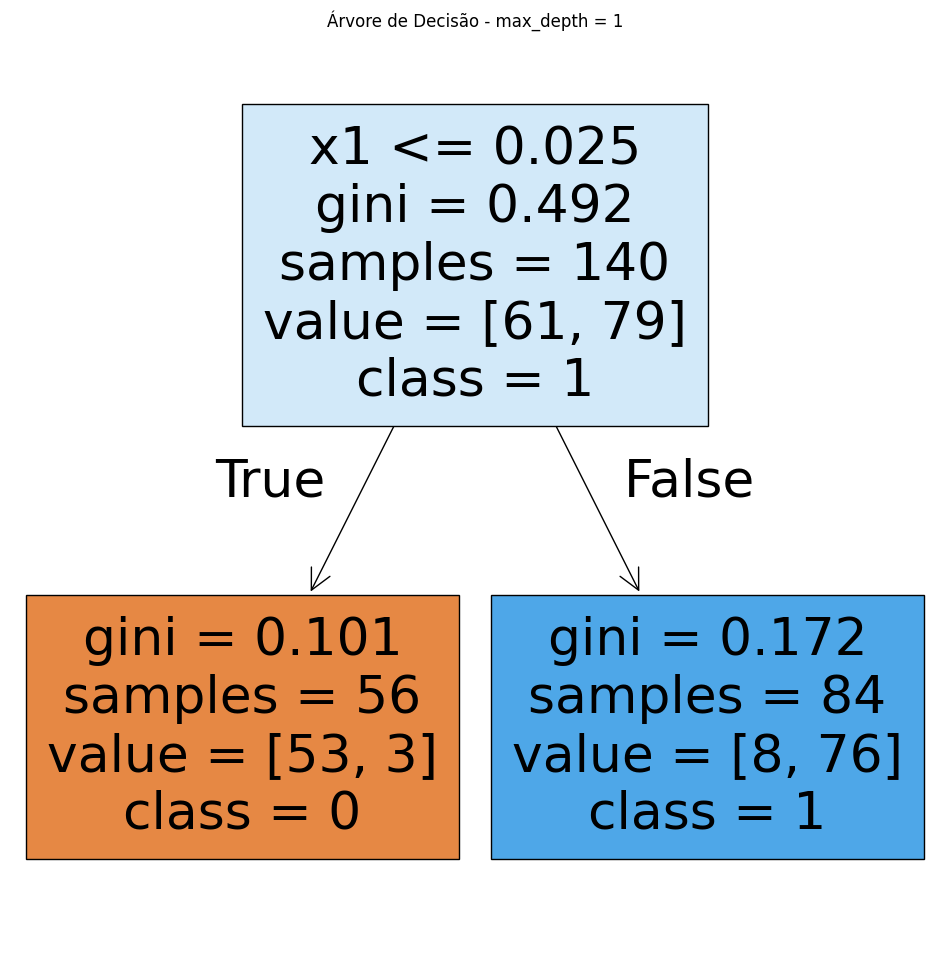

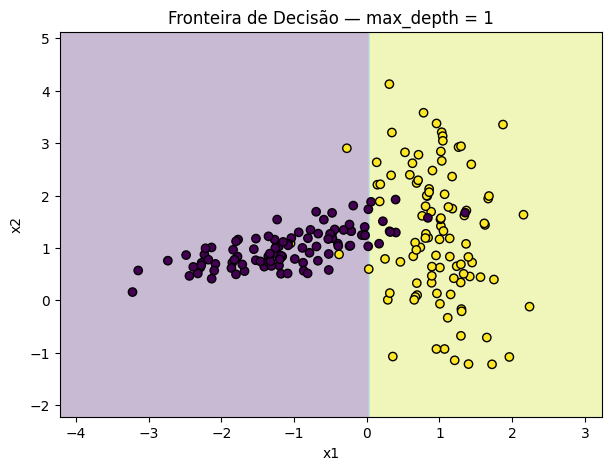

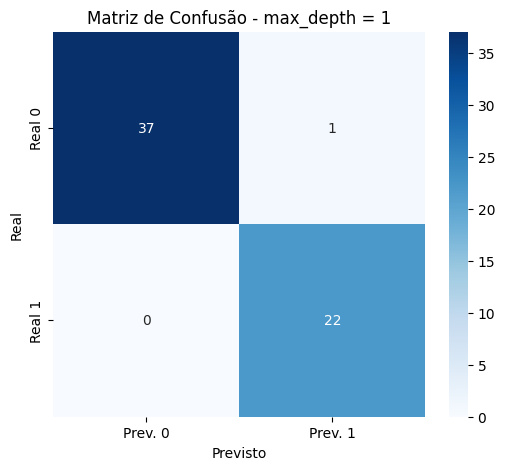

Acertos: 59/60
Acurácia: 0.98


Precisão: 0.96
Recall: 1.00
F1-score: 0.98
Árvore de Decisão com max_depth = 2


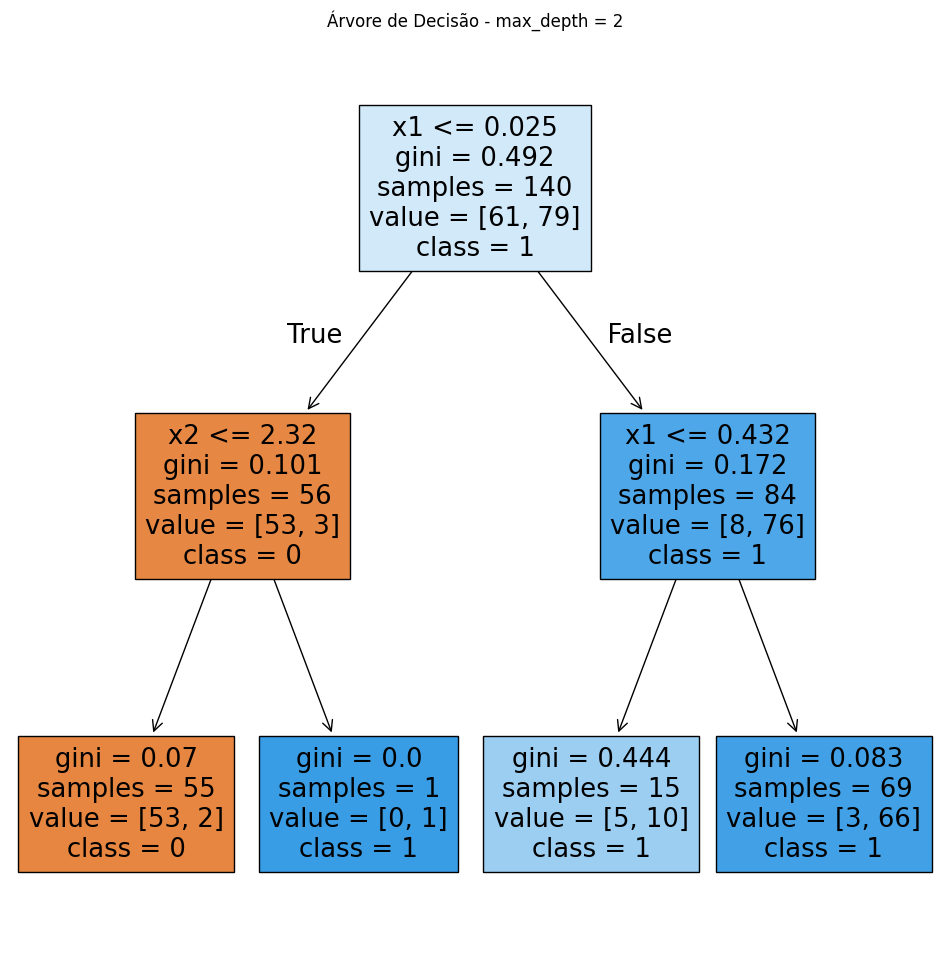

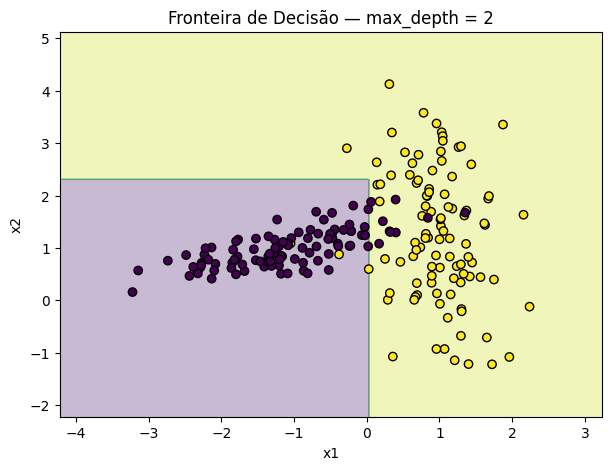

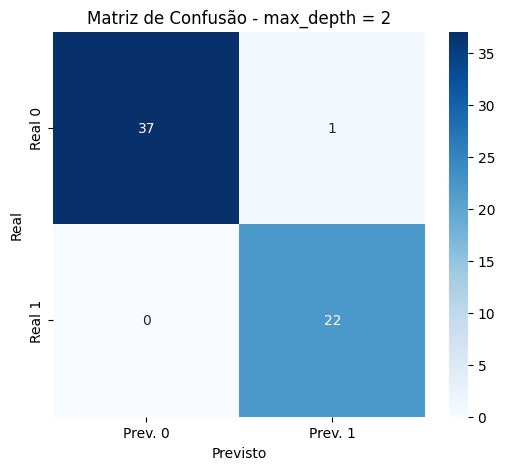

Acertos: 59/60
Acurácia: 0.98


Precisão: 0.96
Recall: 1.00
F1-score: 0.98
Árvore de Decisão com max_depth = 3


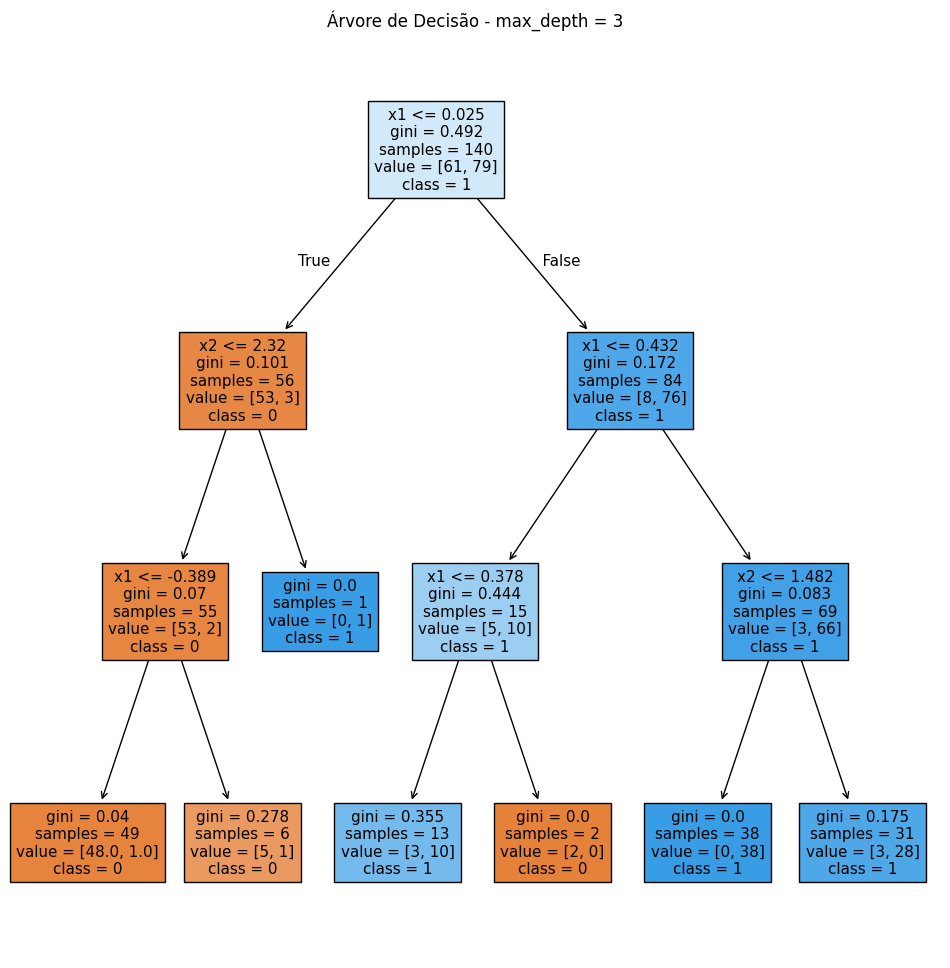

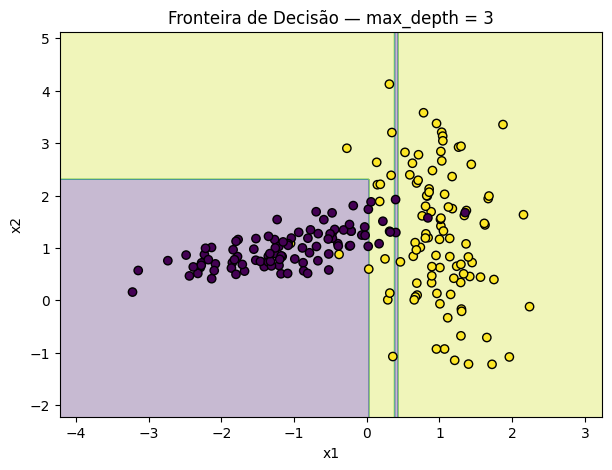

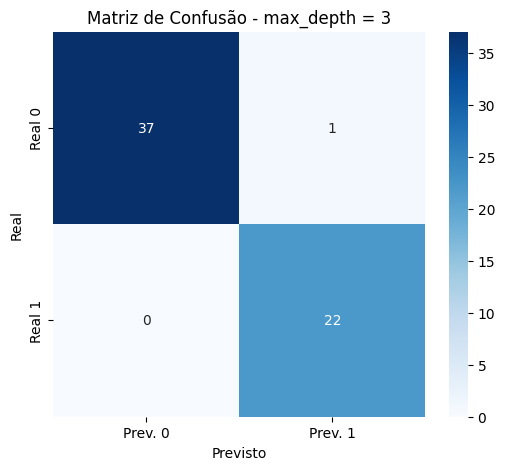

Acertos: 59/60
Acurácia: 0.98


Precisão: 0.96
Recall: 1.00
F1-score: 0.98
Árvore de Decisão com max_depth = 5


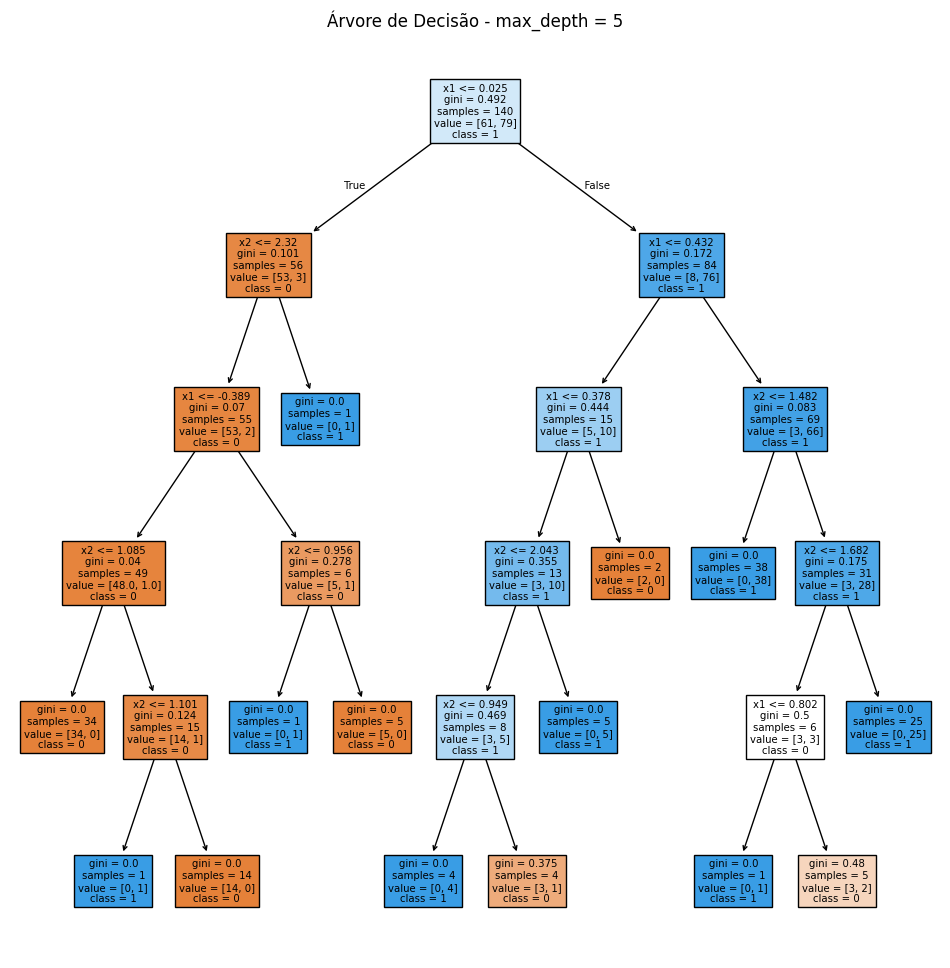

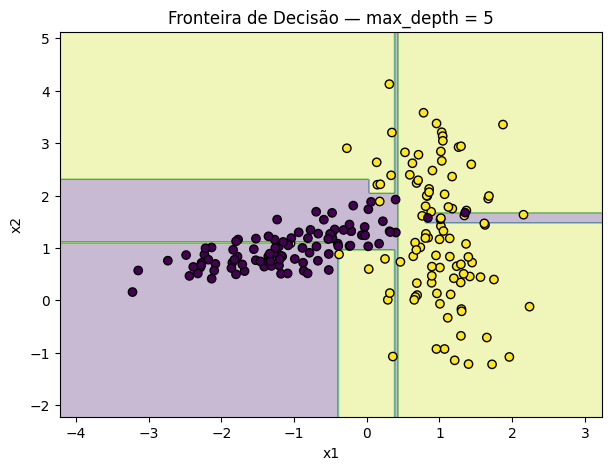

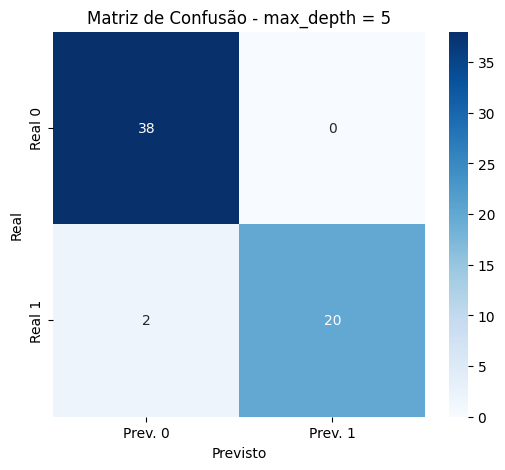

Acertos: 58/60
Acurácia: 0.97


Precisão: 1.00
Recall: 0.91
F1-score: 0.95
Árvore de Decisão com max_depth = None


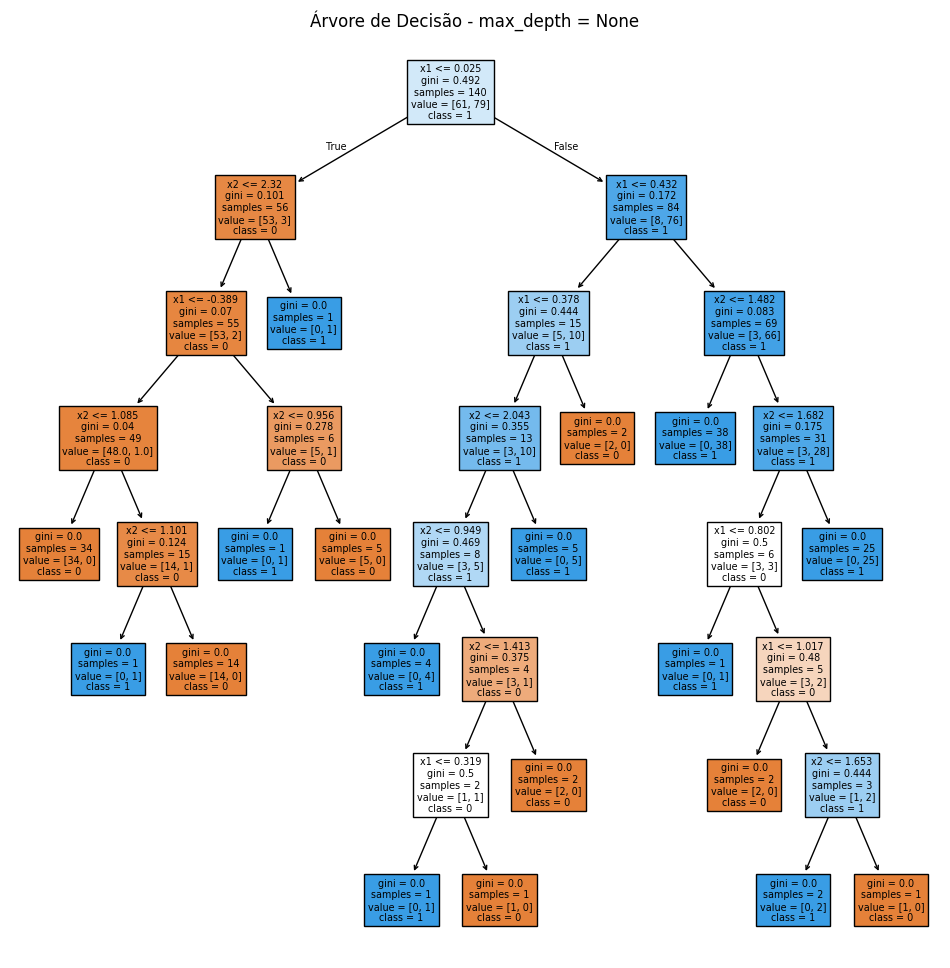

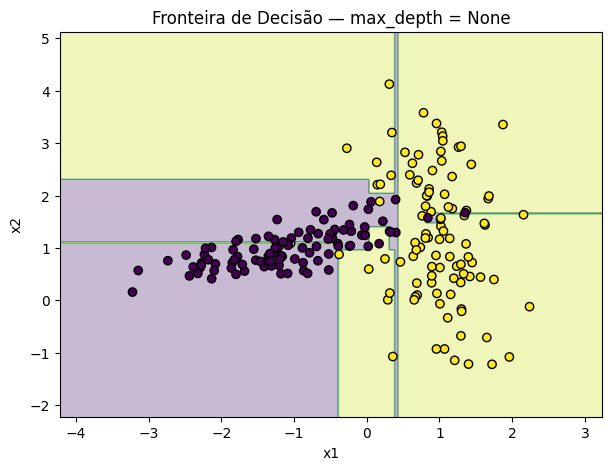

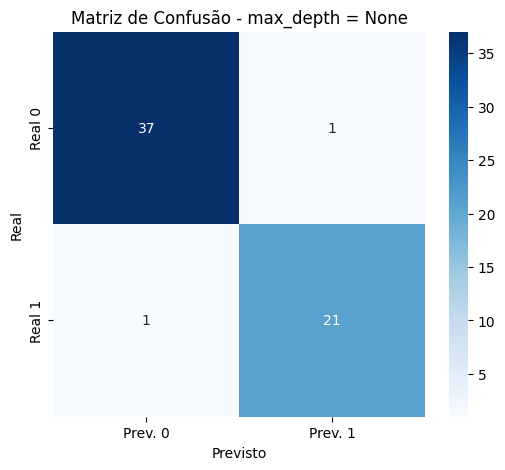

Acertos: 58/60
Acurácia: 0.97


Precisão: 0.95
Recall: 0.95
F1-score: 0.95


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score


X, y = make_classification(n_samples=200, n_features=2,
                           n_redundant=0, n_informative=2,
                           n_clusters_per_class=1, random_state=0)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)


profundidades = [1, 2, 3, 5, None]

for profundidade in profundidades:

    print("=====================================================")
    print(f"Árvore de Decisão com max_depth = {profundidade}")
    print("=====================================================")


    model = DecisionTreeClassifier(max_depth=profundidade, random_state=0)
    model.fit(X_train, y_train)


    plt.figure(figsize=(12,12))
    plot_tree(model, filled=True,
              feature_names=["x1", "x2"],
              class_names=["0", "1"])
    plt.title(f"Árvore de Decisão - max_depth = {profundidade}")
    plt.show()


    xx, yy = np.meshgrid(
        np.linspace(X[:,0].min()-1, X[:,0].max()+1, 300),
        np.linspace(X[:,1].min()-1, X[:,1].max()+1, 300)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(7,5))
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:,0], X[:,1], c=y, edgecolor="k")

    plt.title(f"Fronteira de Decisão — max_depth = {profundidade}")
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.show()

    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Prev. 0", "Prev. 1"],
                yticklabels=["Real 0", "Real 1"])

    plt.title(f"Matriz de Confusão - max_depth = {profundidade}")
    plt.ylabel("Real")
    plt.xlabel("Previsto")
    plt.show()

    acertos = np.sum(y_pred == y_test)
    total = len(y_test)
    acuracia = acertos / total

    print(f"Acertos: {acertos}/{total}")
    print(f"Acurácia: {acuracia:.2f}")
    print("\n")
    precisao = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"Precisão: {precisao:.2f}")
    print(f"Recall: {recall:.2f}")
    print(f"F1-score: {f1:.2f}")

# Análise do Exercício 1

Neste exercício foi analisado o impacto do hiperparâmetro `max_depth` em uma Árvore de Decisão. Esse parâmetro controla a profundidade máxima da árvore, ou seja, quantas divisões sucessivas o modelo pode realizar nos dados.

Quando `max_depth = 1`, a árvore faz apenas uma divisão principal. Nesse caso, o modelo é muito simples e pode não capturar bem a estrutura dos dados. Isso caracteriza um possível caso de underfitting, pois a árvore não tem complexidade suficiente para separar corretamente as classes.

Com `max_depth = 2` e `max_depth = 3`, o modelo passa a criar mais divisões, representando melhor a distribuição dos dados. A fronteira de decisão fica mais adaptada ao problema, mas ainda relativamente simples. Esse costuma ser um bom equilíbrio entre simplicidade e desempenho.

Quando `max_depth = 5`, a árvore se torna mais complexa. Ela consegue criar regiões menores e mais específicas no espaço de decisão. Isso pode melhorar os acertos no conjunto de treino, mas também aumenta o risco de overfitting, principalmente se a árvore começar a aprender detalhes muito específicos dos dados.

Quando `max_depth = None`, a árvore cresce livremente até atingir seus critérios internos de parada. Nesse caso, ela pode se ajustar demais aos dados de treinamento, criando uma fronteira de decisão muito irregular. Embora isso possa gerar bom desempenho no treino, pode reduzir a capacidade de generalização para novos dados.

A matriz de confusão permite observar os acertos e erros do modelo para cada profundidade. Já a fronteira de decisão mostra visualmente como a árvore separa as classes. Portanto, alterar `max_depth` modifica diretamente a complexidade do modelo, influenciando o equilíbrio entre underfitting e overfitting.

## 2) Alterar o dataset e reavaliar o modelo
**Objetivo:**

Explorar como diferentes distribuições de dados afetam o comportamento da árvore.

Modifique o bloco:

X, y = make_classification(...)

Testando diferentes configurações:

1. Aumente o ruído dos rótulos
flip_y=0.15
2. Aumente o número de clusters por classe
n_clusters_per_class=2
3. Aumente o número de features informativas
n_features=4
n_informative=4

Para cada cenário:

1. Refaça o treino.
2. Plote (quando possível).
3. Gere a matriz de confusão.
4. Calcule accuracy, precisão, recall e F1.

**Pergunta final:** Em quais condições o modelo piora mais? Por quê?

Dataset original


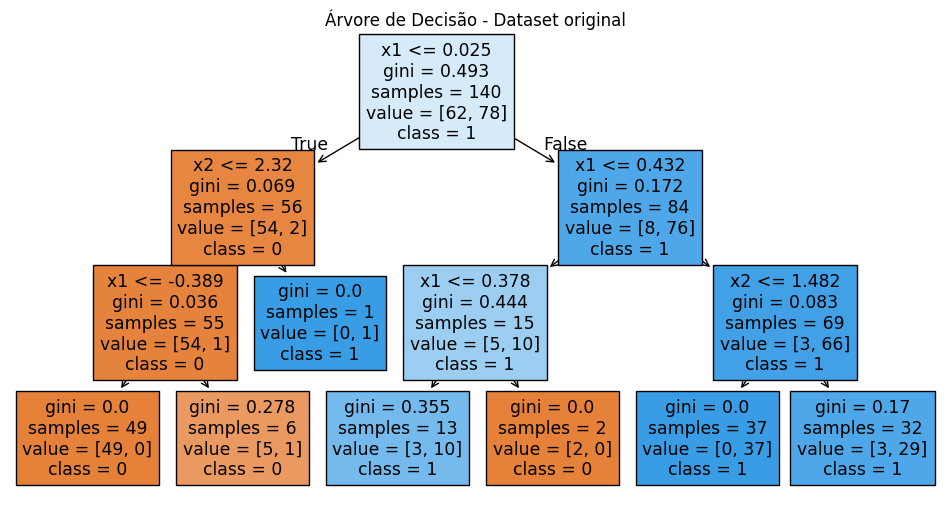

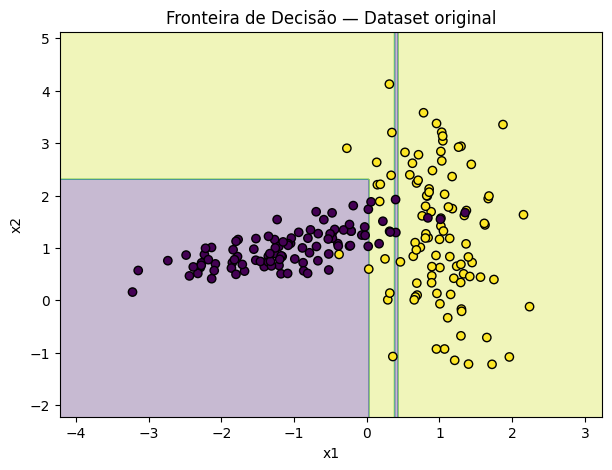

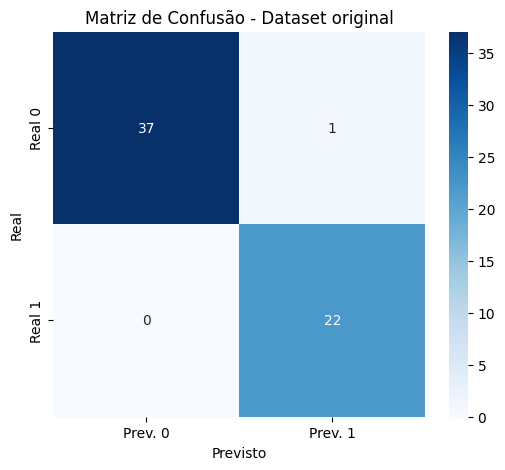

Acertos: 59/60
Acurácia: 0.98
Precisão: 0.96
Recall: 1.00
F1-score: 0.98


Dados com ruído


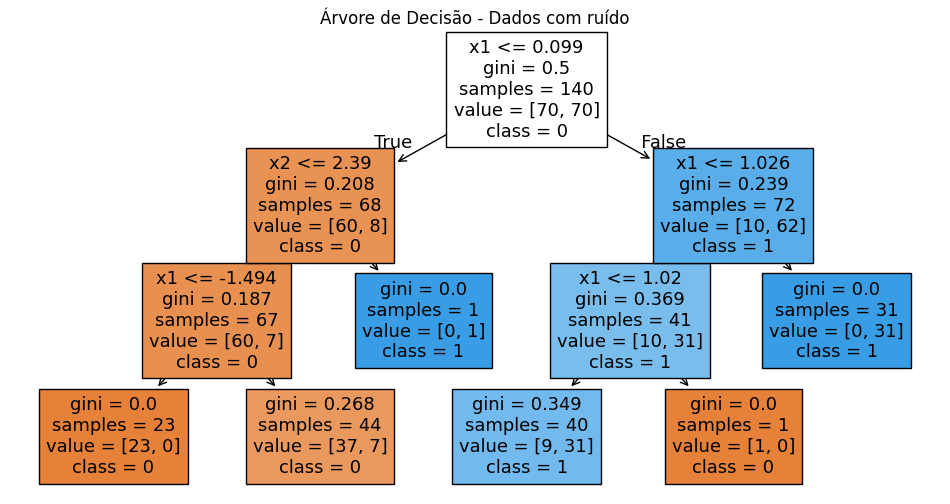

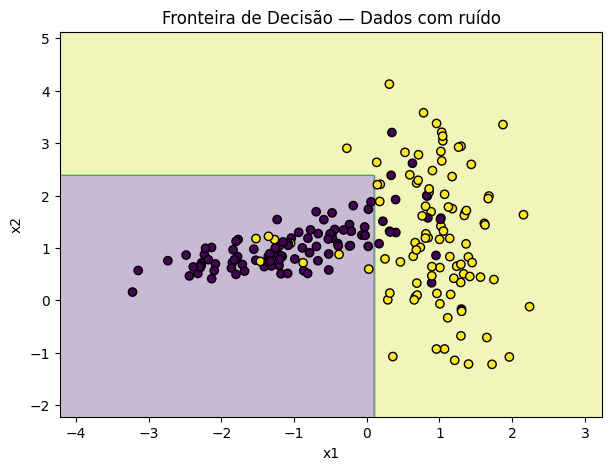

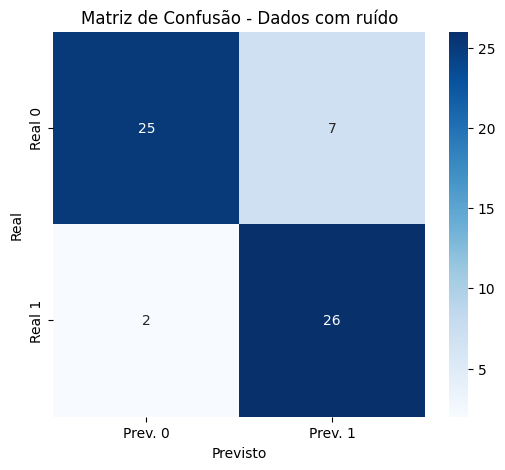

Acertos: 51/60
Acurácia: 0.85
Precisão: 0.79
Recall: 0.93
F1-score: 0.85


Mais clusters por classe


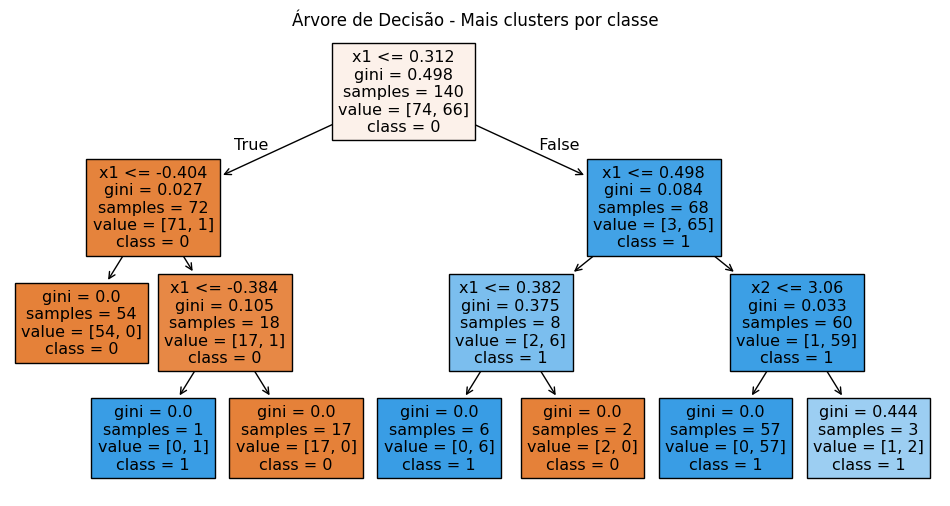

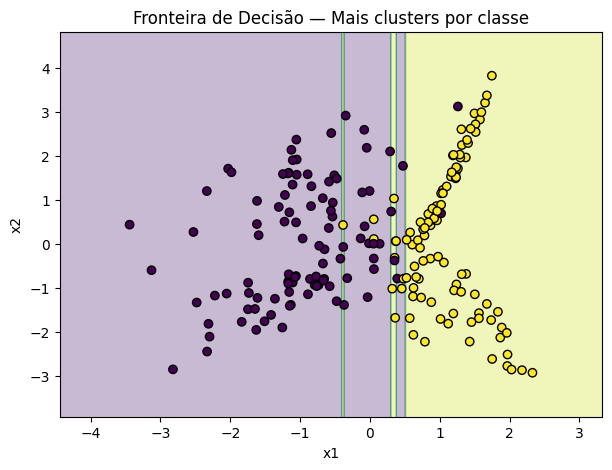

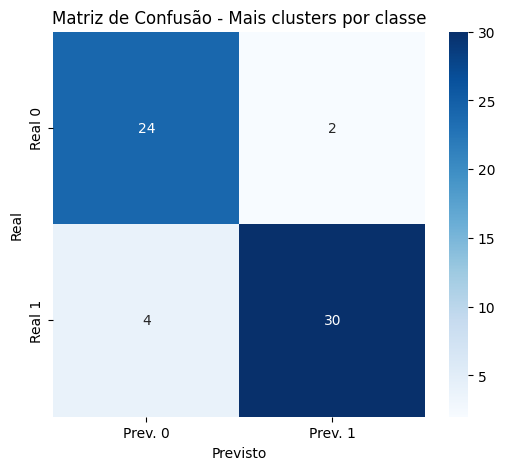

Acertos: 54/60
Acurácia: 0.90
Precisão: 0.94
Recall: 0.88
F1-score: 0.91


Mais features informativas


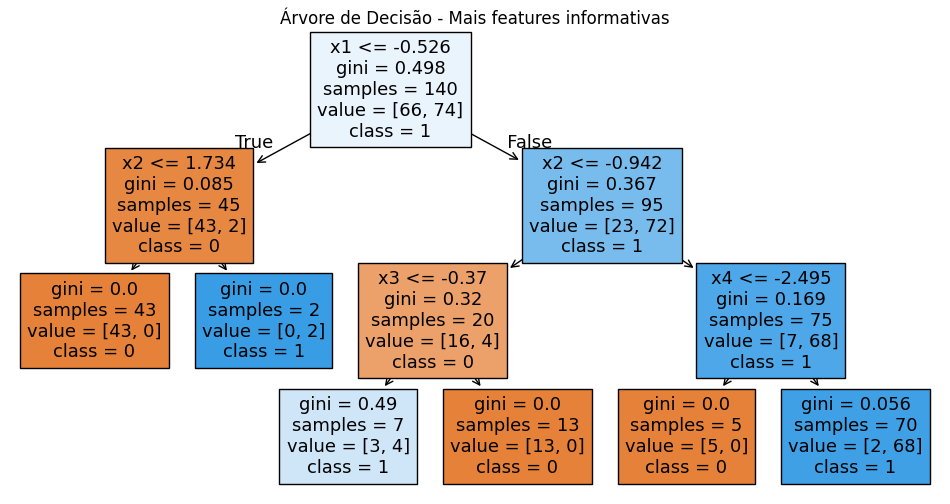

Fronteira de decisão não exibida, pois este dataset possui 4 features.


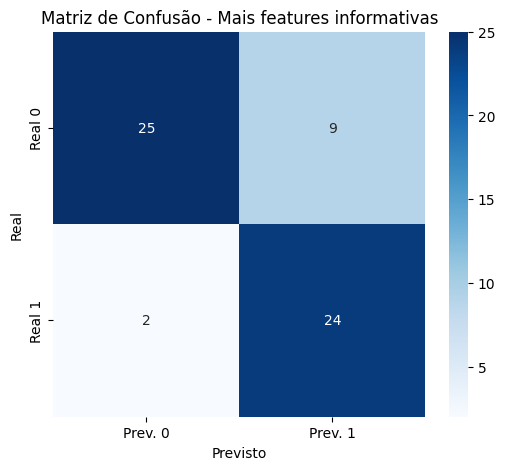

Acertos: 49/60
Acurácia: 0.82
Precisão: 0.73
Recall: 0.92
F1-score: 0.81




In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score


configuracoes = [
    {
        "nome": "Dataset original",
        "n_samples": 200,
        "n_features": 2,
        "n_informative": 2,
        "n_redundant": 0,
        "n_clusters_per_class": 1,
        "class_sep": 1.0,
        "flip_y": 0.0,
        "random_state": 0
    },
    {
        "nome": "Dados com ruído",
        "n_samples": 200,
        "n_features": 2,
        "n_informative": 2,
        "n_redundant": 0,
        "n_clusters_per_class": 1,
        "class_sep": 1.0,
        "flip_y": 0.15,
        "random_state": 0
    },
    {
        "nome": "Mais clusters por classe",
        "n_samples": 200,
        "n_features": 2,
        "n_informative": 2,
        "n_redundant": 0,
        "n_clusters_per_class": 2,
        "class_sep": 1.0,
        "flip_y": 0.0,
        "random_state": 0
    },
    {
        "nome": "Mais features informativas",
        "n_samples": 200,
        "n_features": 4,
        "n_informative": 4,
        "n_redundant": 0,
        "n_clusters_per_class": 1,
        "class_sep": 1.0,
        "flip_y": 0.0,
        "random_state": 0
    }
]


for config in configuracoes:

    print("=====================================================")
    print(config["nome"])
    print("=====================================================")

    X, y = make_classification(
        n_samples=config["n_samples"],
        n_features=config["n_features"],
        n_redundant=config["n_redundant"],
        n_informative=config["n_informative"],
        n_clusters_per_class=config["n_clusters_per_class"],
        class_sep=config["class_sep"],
        flip_y=config["flip_y"],
        random_state=config["random_state"]
    )

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=0
    )

    model = DecisionTreeClassifier(max_depth=3, random_state=0)
    model.fit(X_train, y_train)

    plt.figure(figsize=(12, 6))
    plot_tree(
        model,
        filled=True,
        feature_names=[f"x{i+1}" for i in range(config["n_features"])],
        class_names=["0", "1"]
    )
    plt.title(f"Árvore de Decisão - {config['nome']}")
    plt.show()


    if config["n_features"] == 2:

        xx, yy = np.meshgrid(
            np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 300),
            np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 300)
        )

        Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)

        plt.figure(figsize=(7, 5))
        plt.contourf(xx, yy, Z, alpha=0.3)
        plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k")

        plt.title(f"Fronteira de Decisão — {config['nome']}")
        plt.xlabel("x1")
        plt.ylabel("x2")
        plt.show()

    else:
        print("Fronteira de decisão não exibida, pois este dataset possui 4 features.")

    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Prev. 0", "Prev. 1"],
        yticklabels=["Real 0", "Real 1"]
    )

    plt.title(f"Matriz de Confusão - {config['nome']}")
    plt.ylabel("Real")
    plt.xlabel("Previsto")
    plt.show()

    acertos = np.sum(y_pred == y_test)
    total = len(y_test)
    acuracia = acertos / total

    precisao = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"Acertos: {acertos}/{total}")
    print(f"Acurácia: {acuracia:.2f}")
    print(f"Precisão: {precisao:.2f}")
    print(f"Recall: {recall:.2f}")
    print(f"F1-score: {f1:.2f}")
    print("\n")

# Análise do Exercício 2

Neste exercício, o objetivo foi modificar diferentes parâmetros do conjunto de dados gerado artificialmente e analisar como essas mudanças influenciam o desempenho da Árvore de Decisão. As alterações realizadas permitiram observar como características dos dados podem facilitar ou dificultar o processo de classificação.

No primeiro caso, foi utilizado o dataset original com 200 amostras, duas características (n_features = 2) e duas variáveis informativas (n_informative = 2). Além disso, foi utilizado apenas um cluster por classe (n_clusters_per_class = 1) e nenhum ruído nos rótulos (flip_y = 0.0). Esse cenário representa um problema relativamente simples, servindo como referência para comparação com os demais casos analisados.

No caso dos dados com ruído (flip_y = 0.15), parte dos rótulos das amostras foi alterada aleatoriamente. Isso simula situações reais em que os dados possuem erros, inconsistências ou medições incorretas. Como consequência, a Árvore de Decisão encontra maior dificuldade para identificar padrões corretos, podendo criar divisões inadequadas e aumentar a quantidade de erros na matriz de confusão. Além disso, o ruído aumenta a possibilidade de overfitting, pois o modelo pode tentar aprender informações aleatórias presentes no dataset.

Quando aumentamos o número de clusters por classe (n_clusters_per_class = 2), cada classe passou a possuir mais de uma região de distribuição no espaço das características. Isso torna o problema mais complexo, já que os dados deixam de estar concentrados em apenas uma região. Nesse cenário, a Árvore de Decisão precisa criar mais divisões para separar corretamente as classes, o que normalmente resulta em fronteiras de decisão mais complexas e maior dificuldade de classificação.

No último caso, aumentamos o número de características para quatro (n_features = 4) e definimos todas elas como informativas (n_informative = 4). Isso significa que o modelo passou a trabalhar com um espaço de maior dimensionalidade e mais informações relevantes. Em muitos casos, isso pode melhorar a capacidade de classificação, pois existem mais dados úteis para separar as classes. Porém, o aumento da dimensionalidade também pode tornar o treinamento mais complexo e dificultar a visualização gráfica da fronteira de decisão, já que ela não pode mais ser representada facilmente em apenas dois eixos.

De forma geral, os resultados mostram que o desempenho da Árvore de Decisão depende fortemente das características do conjunto de dados. Dados mais organizados e bem separados facilitam o aprendizado do modelo, enquanto ruído, múltiplos clusters e aumento da complexidade dos dados tornam a classificação mais difícil. Essa análise demonstra a importância do pré-processamento e da compreensão dos dados antes da aplicação de algoritmos de Machine Learning.